# EDA 

In [1]:
# importing the nessary package for EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from scipy.stats import skew

In [2]:
def basic_eda(df):
    print(df.shape)
    print("-" * 30)
    print(df.columns)
    print("-" * 30)
    print(df.dtypes)
    print("-" * 30)
    print((df.isnull().mean()).sort_values(ascending = False ))
    print("-" * 30)
    
# Check for class imbalance if the target is categorical
def class_balance(target):
    if target.dtype != int or  target.dtype != float:
        print(target.value_counts(normalize=True))

In [3]:
# import the data
path = r'E:\Imarticus_ Learning\Jobs - 2026\Models\data\unzipped'
lir_df = pd.read_csv(path + r'\Life Expectancy Data.csv')
"""
lir_df = pd.read_csv(path + r'\Life Expectancy Data.csv'
    # suppoese the columns are not expecting , we can run this to extract data that sperated by diffrent delimitter 
    sep = "Delimiter",
    # if suppose the column name is embedded in the rows we can indicate like this to show which row is the header
    header = row index,
    # if we are aware of the data and we don't need all the columns and need specific colums we can use this.
    # must be given in list
    usecols = ['column names'],
    # if we want call the index by any other columns like month or year or already present index column
    index_col = ['column name'], # we can give one or more columns resonable if there no more than two, we call it like this also df.loc[(year_index, month_index, day_index)]
    # if the data has any indicator comments we can use this to avoid it and must start with # or some specific value
    comment = '#',
    # let's say we have some headings , sub headings for information,  before starting the data we can indicate to 
    # avaid that and  tell Where to start
    skiprows=None,
    # suppose there are NA values indicated as - or unkown or no info we can mark it as nan to regonize it
    na_values = ['--', 'unknown', 'no_info'],
    # telling which columns are dates, If you want pandas to parse a specific column, give that column name:
    parse_dates=["date"] / parse_dates={"datetime": ["year", "month", "day"]},
    #Indicate number of rows to read (useful for large files)
    nrows=500,
    # Encoding to use when reading file
    encoding="utf-8",
    )
"""
lir_df.describe(include = 'all')


<>:4: SyntaxWarning: invalid escape sequence '\L'
<>:4: SyntaxWarning: invalid escape sequence '\L'
C:\Users\paul_\AppData\Local\Temp\ipykernel_4816\1471402090.py:4: SyntaxWarning: invalid escape sequence '\L'
  """


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938,2938.000000,2938,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
unique,193,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,Developing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,16,NaN,2426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2007.518720,NaN,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,NaN,4.613841,NaN,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,NaN,2000.000000,NaN,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,NaN,2004.000000,NaN,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,NaN,2008.000000,NaN,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,NaN,2012.000000,NaN,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000


In [4]:
lir_df.duplicated().sum()

0

In [5]:
lir_df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [6]:
basic_eda(lir_df)

(2938, 22)
------------------------------
Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')
------------------------------
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                 

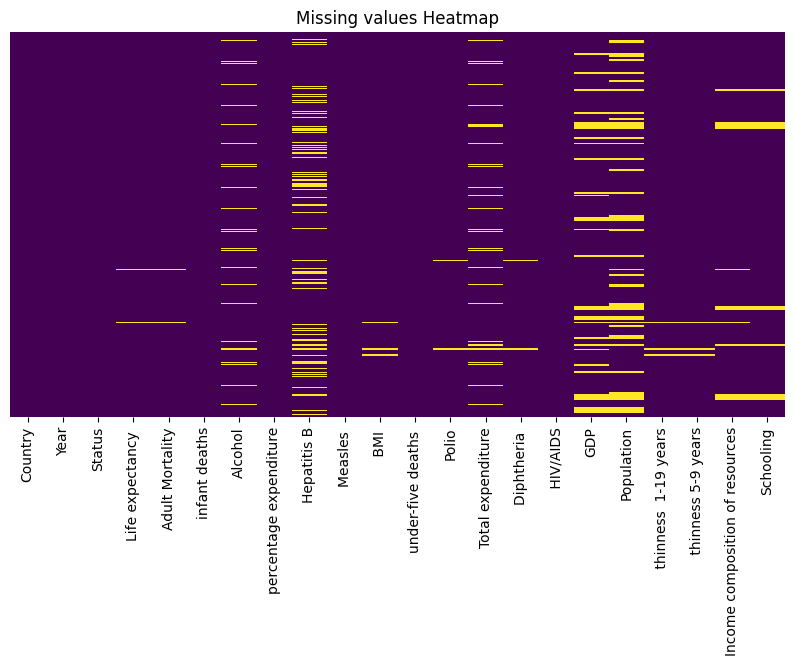

In [7]:
plt.figure(figsize=(10,5))
sns.heatmap(lir_df.isnull(), cbar = False, cmap='viridis', yticklabels=False)
plt.title('Missing values Heatmap')
plt.show()


### There are missing values in Hepatitis B , GDP, Population has missing value more than 15%
### there are colums with less than 8 percent which are Alcohol, BMI, Total expenditure, thinness 1-19 years, thinness 5-9 years , Income composition of resources
### GDP', 'Population' -- with this we can calculate the GDP per captia and use that as a feature.

### There are 10 missing values in the Life expectancy column so we are removing that values as it won't affect the prediction

In [8]:
lir_df = lir_df[lir_df['Life expectancy '].notnull()]

In [9]:
df = lir_df.groupby(['Country'])['Population'].mean().reset_index()
df.loc[df['Population'].isna()]

,Country,Population
4,Antigua and Barbuda,NaN
10,Bahamas,NaN
11,Bahrain,NaN
13,Barbados,NaN
19,Bolivia (Plurinational State of),NaN
23,Brunei Darussalam,NaN
37,Congo,NaN
40,Cuba,NaN
42,Czechia,NaN
43,Côte d'Ivoire,NaN


### Due to the country missing their population is due to the population is not taken also for life expectency the poplulation is not an important predictor so we are droping the column

In [10]:
hep_miss_df = lir_df.loc[lir_df['Hepatitis B'].isna()]
hep_miss_df.shape

(553, 22)

In [11]:
hep_miss_df.head(20).sort_values(by=['Country','Year'])

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
47,Algeria,2000,Developing,71.3,145.0,21,0.25,154.455944,NaN,0,44.4,25,86.0,3.49,86.0,0.1,1757.177970,3118366.0,6.5,6.4,0.636,10.7
46,Algeria,2001,Developing,71.4,145.0,20,0.23,147.986071,NaN,2686,45.3,24,89.0,3.84,89.0,0.1,1732.857979,31592153.0,6.4,6.3,0.644,10.9
45,Algeria,2002,Developing,71.6,145.0,20,0.36,148.511984,NaN,5862,46.1,23,86.0,3.73,86.0,0.1,1774.336730,3199546.0,6.3,6.2,0.653,11.1
44,Algeria,2003,Developing,71.7,146.0,20,0.34,25.018523,NaN,15374,47.0,23,87.0,3.60,87.0,0.1,294.335560,3243514.0,6.3,6.1,0.663,11.5
63,Angola,2000,Developing,45.3,48.0,97,1.85,15.881493,NaN,2219,15.4,160,3.0,2.79,28.0,2.0,555.296942,1644924.0,1.9,1.9,0.382,4.6
62,Angola,2001,Developing,45.7,44.0,97,2.58,30.359936,NaN,9046,15.8,159,41.0,5.38,38.0,2.1,526.168743,16983266.0,1.7,1.7,0.391,5.1
61,Angola,2002,Developing,46.5,391.0,96,2.82,24.037942,NaN,11945,16.3,157,37.0,3.63,41.0,2.3,711.181716,17572649.0,1.5,1.5,0.401,5.5
60,Angola,2003,Developing,46.8,388.0,95,3.49,35.933491,NaN,1196,16.8,155,4.0,4.41,4.0,2.4,779.468356,1823369.0,1.4,1.3,0.406,5.9
59,Angola,2004,Developing,47.1,386.0,94,3.53,8.866777,NaN,29,17.2,152,4.0,4.71,4.0,2.5,141.868440,18865716.0,1.2,1.1,0.415,6.4
58,Angola,2005,Developing,47.4,382.0,92,5.04,98.191451,NaN,258,17.7,148,39.0,4.10,38.0,2.6,1443.991929,19552542.0,1.0,9.9,0.426,6.8


In [13]:
lir_df[lir_df['Country'] == 'Algeria'][['Year', 'Hepatitis B']]

,Year,Hepatitis B
32,2015,95.0
33,2014,95.0
34,2013,95.0
35,2012,95.0
36,2011,95.0
37,2010,95.0
38,2009,94.0
39,2008,91.0
40,2007,9.0
41,2006,8.0


In [15]:
missing_by_year = hep_miss_df[hep_miss_df['Hepatitis B'].isna()].groupby('Year').size()
print(missing_by_year)


Year
2000    98
2001    88
2002    70
2003    52
2004    45
2005    36
2006    32
2007    24
2008    20
2009    17
2010    15
2011    13
2012    13
2013    11
2014    10
2015     9
dtype: int64


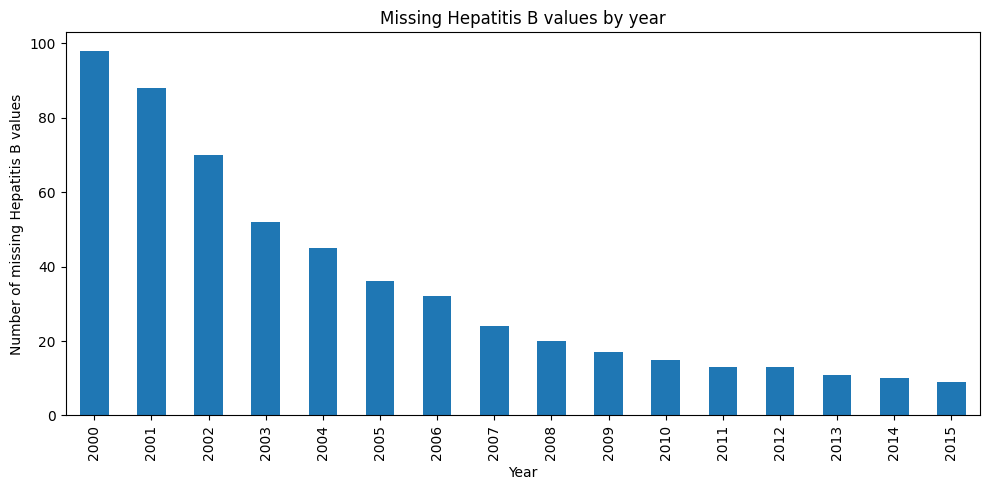

In [18]:
plt.figure(figsize=(10, 5))
missing_by_year.plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of missing Hepatitis B values')
plt.title('Missing Hepatitis B values by year')
plt.tight_layout()
plt.show()


# Based on the above observation we can say that, In the early years there are more missing values 

<Axes: ylabel='Frequency'>

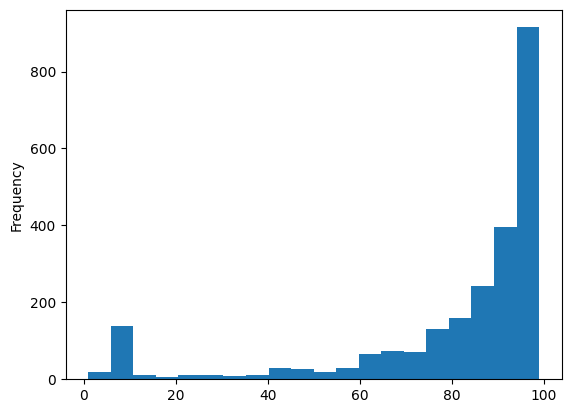

In [12]:
lir_df['Hepatitis B'].plot(
    kind= 'hist',
    bins = 20
)

In [19]:
lir_df['Hepatitis B'].skew()

-1.933773510510973

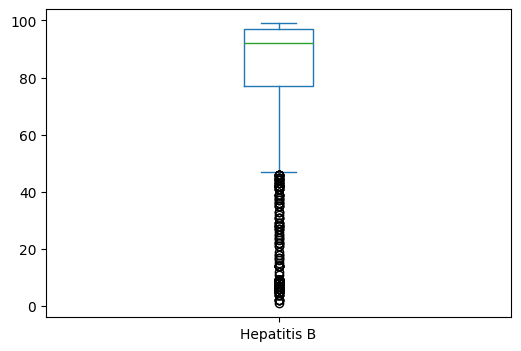

In [20]:
plt.figure(figsize=(6,4))
lir_df['Hepatitis B'].plot(kind='box')
plt.show()

In [21]:
print("Skewness:", lir_df['Hepatitis B'].skew())
print("Median:", lir_df['Hepatitis B'].median())
print("Mean:", lir_df['Hepatitis B'].mean())

Skewness: -1.933773510510973
Median: 92.0
Mean: 80.96084210526315
